This first bit is already in the MS3 notebook, the new thresholding info begins where it says START HERE.

In [2]:
!pip install kagglehub
# Standard library
import os
import gc
import time
import warnings

# Numerical computing and data processing
import numpy as np
import pandas as pd
import random
from pathlib import Path
from collections import Counter
import zipfile

# external utilities
import kagglehub
import hashlib

# Visualization
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from torchvision import datasets, models, transforms
from torchvision.models import ResNet50_Weights
from torchvision import transforms

# UMAP
#import umap
from tqdm import tqdm
import umap
from umap import UMAP


Defaulting to user installation because normal site-packages is not writeable


In [3]:
# Suppress warnings
warnings.filterwarnings('ignore')

load data

In [4]:
path = kagglehub.dataset_download("jangedoo/utkface-new")
utk_path = next(Path(path).rglob("UTKFace"))

print("Path Exists  :", utk_path.exists())

print(f"\nDataset downloaded to:", utk_path)

# put image paths into Dataset, make all RGB, count how many
class FlatImageDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = Path(img_dir)
        self.files   = [f for f in self.img_dir.rglob("*")
                        if f.name.endswith(".jpg")
                        or f.name.endswith(".jpeg")
                        or f.name.endswith(".png")]
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.files[idx].name

dataset = FlatImageDataset(utk_path)

size = 0
img_count = 0
for dirpath, dirnames, filenames in os.walk(utk_path):
    for f in filenames:
        fp = os.path.join(dirpath, f)
        size += os.path.getsize(fp)
        img_count += 1

print(f"Number of images : {img_count}")
print(f"Size on disk   : {size / (1024**2):.2f} MB")

Path Exists  : True

Dataset downloaded to: /shared/home/jea040/.cache/kagglehub/datasets/jangedoo/utkface-new/versions/1/UTKFace
Number of images : 23708
Size on disk   : 114.43 MB


preprocess data

In [5]:
print("Hashing images...")

def hash_image(img):
    """Generate MD5 hash from image pixels (fingerprint of image)."""
    return hashlib.md5(np.array(img).tobytes()).hexdigest()

# --- compute hashes directly from image files from Dataset object ---
hashes = []
images = []

for p in dataset.files:
    img = Image.open(p).convert("RGB")
    images.append(img)
    hashes.append(hash_image(img))

df = pd.DataFrame({
    "path": dataset.files,
    "image": images,
    "hash": hashes
})

# --- duplicate analysis ---
n_before = len(df)
dup_mask = df.duplicated(subset='hash', keep='first')
num_removed = dup_mask.sum()

print(f"Total images before : {n_before}")
print(f"Duplicate images removed : {num_removed}")

# --- keep only first occurrence of each image ---
df = df.drop_duplicates(subset='hash', keep='first').reset_index(drop=True)

print("\nDataset cleaned.")
print(f"Non-duplicated dataset size : {len(df)}")


# Build a labeled UTKFace dataset by parsing age/gender/race from filenames, 
#loading images into a DataFrame, and wrapping it in a PyTorch Dataset with 
#tensor conversion for model training
def parse_utk_filename(filename):
    parts = filename.split("_")

    try:
        age = int(parts[0])
        gender = int(parts[1])
        race = int(parts[2])
        return age, gender, race
    except:
        return None  # invalid file

class DFDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        img    = row['image']
        age    = row['age']
        gender = row['gender']
        race   = row['race']

        if self.transform:
            img = self.transform(img)

        #make friendly for pytorch
        return img, torch.tensor(age), torch.tensor(gender), torch.tensor(race)
        
rows = []

for p in dataset.files:
    parsed = parse_utk_filename(p.name)

    # skip bad files
    if parsed is None:
        continue

    age, gender, race = parsed

    img = Image.open(p).convert("RGB")

    rows.append({
        "image": img,
        "age": age,
        "gender": gender,
        "race": race,
        "hash": hash_image(img)
    })

df = pd.DataFrame(rows)
transform = transforms.Compose([
    transforms.ToTensor(),
])

clean_dataset = DFDataset(df, transform=transform)

print(f"Clean dataset size: {len(clean_dataset):,} images")




Hashing images...
Total images before : 23708
Duplicate images removed : 390

Dataset cleaned.
Non-duplicated dataset size : 23318
Clean dataset size: 23,705 images


# START HERE

# Second Pass ResNet

In order to implement some of the correction methods we ideated, we need to be able to adjust the model's thresholding by race. To do that, we must allow the model to access the racial information of each image, which we didn't do in our first pass model. Here, we use the same ResNet18 model but add a new classifier head that predicts race (this is working under the assumption that when models are fed images, they are not explicitly told the race of the person in the image). This way, we can optimize race prediction in a supervised manner, which in turn trains the model's ability to make an informed decision about which gender/age prediction threshold to use in the final classification layer.

In [6]:
labels = ["0_5",      # infants / toddlers
          "5_13",     # children
          "13_20",    # teens
          "21_40",
          "41_60",
          "61_80",
          "80_plus"
]

df["eval_age_bin"] = pd.cut(
    df["age"],
    bins=[0, 5, 13, 20, 40, 60, 80, 120],
    labels=["0_5", "5_13", "13_20", "21_40", "41_60", "61_80", "80_plus"],
    include_lowest=True
)

race_map = {
    0: "White",
    1: "Black",
    2: "Asian",
    3: "Indian",
    4: "Other"
}

gender_map = {
    0: "Male",
    1: "Female"
}

IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

Define and train the 3-head model.

In [23]:
class MultiTaskResNet(nn.Module):
    def __init__(self, num_races=5):
        super().__init__()

        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.age_head = nn.Linear(in_features, 1)      
        self.gender_head = nn.Linear(in_features, 1)    
        self.race_head = nn.Linear(in_features, num_races)     

    def forward(self, x):
        features = self.backbone(x)

        age_pred = self.age_head(features).squeeze(1)
        gender_logit = self.gender_head(features).squeeze(1)
        race_logits = self.race_head(features)

        return age_pred, gender_logit, race_logits

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet_model = MultiTaskResNet(num_races=5).to(device)

age_criterion = nn.L1Loss()
gender_criterion = nn.BCEWithLogitsLoss()
race_criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(resnet_model.parameters(), lr=1e-4)


def train_one_epoch(model, loader, optimizer, age_criterion, gender_criterion, race_criterion, device):
    model.train()

    total_loss = 0.0
    total_age_loss = 0.0
    total_gender_loss = 0.0
    total_race_loss = 0.0

    for images, ages, genders, races, _ in loader:
        images = images.to(device)
        ages = ages.to(device)
        genders = genders.to(device)
        races = races.to(device)

        optimizer.zero_grad()

        age_pred, gender_logit, race_logits = model(images)

        age_loss = age_criterion(age_pred, ages)
        gender_loss = gender_criterion(gender_logit, genders)
        race_loss = race_criterion(race_logits, races)

        loss = age_loss + gender_loss + race_loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total_age_loss += age_loss.item() * images.size(0)
        total_gender_loss += gender_loss.item() * images.size(0)
        total_race_loss += race_loss.item() * images.size(0)

    n = len(loader.dataset)

    return {
        "loss": total_loss / n,
        "age_loss": total_age_loss / n,
        "gender_loss": total_gender_loss / n,
        "race_loss": total_race_loss / n
    }


def evaluate(model, loader, age_criterion, gender_criterion, race_criterion, device):
    model.eval()

    total_loss = 0.0
    total_age_loss = 0.0
    total_gender_loss = 0.0
    total_race_loss = 0.0

    all_age_preds = []
    all_ages = []
    all_gender_preds = []
    all_genders = []
    all_race_preds = []
    all_races = []

    with torch.no_grad():
        for images, ages, genders, races, _ in loader:
            images = images.to(device)
            ages = ages.to(device)
            genders = genders.to(device)
            races = races.to(device)

            age_pred, gender_logit, race_logits = model(images)

            age_loss = age_criterion(age_pred, ages)
            gender_loss = gender_criterion(gender_logit, genders)
            race_loss = race_criterion(race_logits, races)

            loss = age_loss + gender_loss + race_loss

            total_loss += loss.item() * images.size(0)
            total_age_loss += age_loss.item() * images.size(0)
            total_gender_loss += gender_loss.item() * images.size(0)
            total_race_loss += race_loss.item() * images.size(0)

            gender_probs = torch.sigmoid(gender_logit)
            gender_preds = (gender_probs >= 0.5).float()

            race_preds = torch.argmax(race_logits, dim=1)

            all_age_preds.append(age_pred.cpu())
            all_ages.append(ages.cpu())
            all_gender_preds.append(gender_preds.cpu())
            all_genders.append(genders.cpu())
            all_race_preds.append(race_preds.cpu())
            all_races.append(races.cpu())

    all_age_preds = torch.cat(all_age_preds)
    all_ages = torch.cat(all_ages)
    all_gender_preds = torch.cat(all_gender_preds)
    all_genders = torch.cat(all_genders)
    all_race_preds = torch.cat(all_race_preds)
    all_races = torch.cat(all_races)

    age_mae = torch.mean(torch.abs(all_age_preds - all_ages)).item()
    gender_acc = (all_gender_preds == all_genders).float().mean().item()
    race_acc = (all_race_preds == all_races).float().mean().item()

    n = len(loader.dataset)

    return {
        "loss": total_loss / n,
        "age_loss": total_age_loss / n,
        "gender_loss": total_gender_loss / n,
        "race_loss": total_race_loss / n,
        "age_mae": age_mae,
        "gender_acc": gender_acc,
        "race_acc": race_acc
    }

In [24]:
class UTKFaceDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = row["image"]

        if self.transform:
            image = self.transform(image)

        age = torch.tensor(row["age"], dtype=torch.float32)
        gender = torch.tensor(row["gender"], dtype=torch.float32)

        race = torch.tensor(row["race"], dtype=torch.long) 
        age_bin = str(row["eval_age_bin"])

        return image, age, gender, race, age_bin


df["stratify_key"] = (
    df["race"].astype(str) + "_" +
    df["gender"].astype(str)
)

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["stratify_key"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["stratify_key"]
)

print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")


train_dataset = UTKFaceDataset(train_df, transform=train_transform)
val_dataset = UTKFaceDataset(val_df, transform=val_transform)
test_dataset = UTKFaceDataset(test_df, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)


Train size: 16593
Validation size: 3556
Test size: 3556


In [25]:
num_epochs = 10

history = {
    "train_loss": [],
    "val_loss": [],
    "val_age_mae": [],
    "val_gender_acc": [],
    "val_race_acc": []
}

best_val_mae = float("inf")
best_gender_acc = 0.0

start_time = time.time()

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(
        resnet_model, train_loader, optimizer,
        age_criterion, gender_criterion, race_criterion, device
    )

    val_metrics = evaluate(
        resnet_model, val_loader,
        age_criterion, gender_criterion, race_criterion, device
    )

    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["val_age_mae"].append(val_metrics["age_mae"])
    history["val_gender_acc"].append(val_metrics["gender_acc"])
    history["val_race_acc"].append(val_metrics["race_acc"])

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {train_metrics['loss']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Age MAE: {val_metrics['age_mae']:.2f} | "
        f"Gender Acc: {val_metrics['gender_acc']:.3f} | "
        f"Race Acc: {val_metrics['race_acc']:.3f}"
    )

    if (
        val_metrics["age_mae"] < best_val_mae or
        (
            abs(val_metrics["age_mae"] - best_val_mae) < 1e-4
            and val_metrics["gender_acc"] > best_gender_acc
        )
    ):
        best_val_mae = val_metrics["age_mae"]
        best_gender_acc = val_metrics["gender_acc"]
        torch.save({
            "model_state_dict": resnet_model.state_dict(),
            "model_type": "resnet_3head",
            "val_mae": best_val_mae
        }, "best_resnet_3head.pt")        
        print("  → Saved new best model")

end_time = time.time()
total_time = end_time - start_time
print(f"\nTotal training time: {total_time:.2f} seconds ({total_time/60:.2f} minutes)")

Epoch 01 | Train Loss: 25.5031 | Val Loss: 17.9607 | Age MAE: 16.93 | Gender Acc: 0.885 | Race Acc: 0.761
  → Saved new best model
Epoch 02 | Train Loss: 11.5815 | Val Loss: 7.2840 | Age MAE: 6.34 | Gender Acc: 0.903 | Race Acc: 0.753
  → Saved new best model
Epoch 03 | Train Loss: 6.5898 | Val Loss: 6.1536 | Age MAE: 5.40 | Gender Acc: 0.913 | Race Acc: 0.811
  → Saved new best model
Epoch 04 | Train Loss: 5.8937 | Val Loss: 5.7815 | Age MAE: 5.08 | Gender Acc: 0.920 | Race Acc: 0.825
  → Saved new best model
Epoch 05 | Train Loss: 5.3480 | Val Loss: 5.6914 | Age MAE: 4.99 | Gender Acc: 0.925 | Race Acc: 0.827
  → Saved new best model
Epoch 06 | Train Loss: 5.0415 | Val Loss: 6.2088 | Age MAE: 5.51 | Gender Acc: 0.922 | Race Acc: 0.829
Epoch 07 | Train Loss: 4.7886 | Val Loss: 5.7243 | Age MAE: 5.04 | Gender Acc: 0.926 | Race Acc: 0.836
Epoch 08 | Train Loss: 4.6278 | Val Loss: 5.6833 | Age MAE: 4.97 | Gender Acc: 0.924 | Race Acc: 0.830
  → Saved new best model
Epoch 09 | Train Loss:

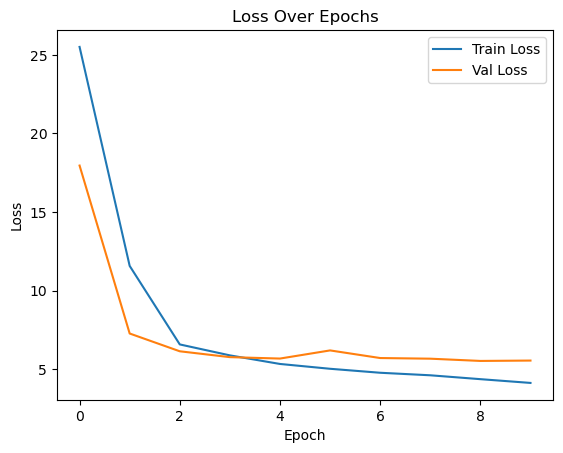

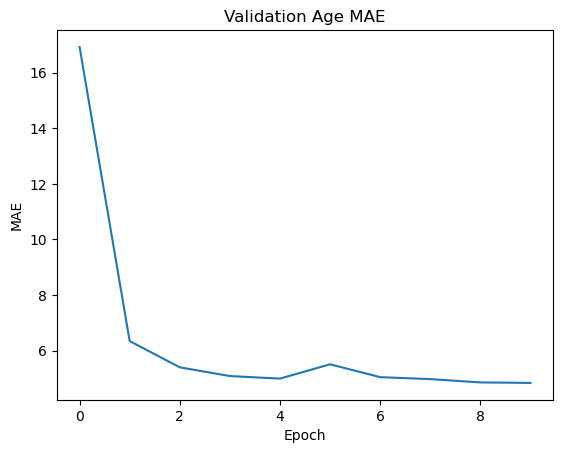

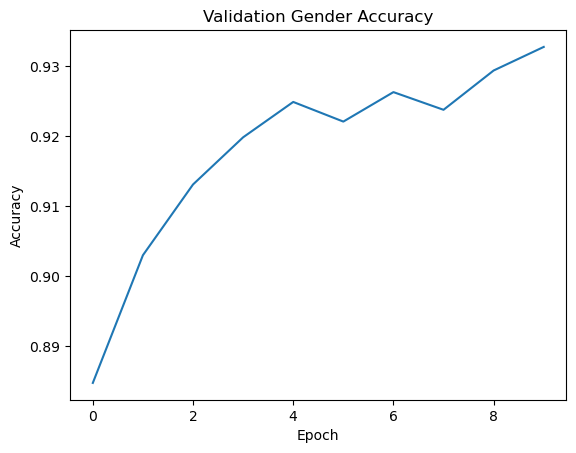

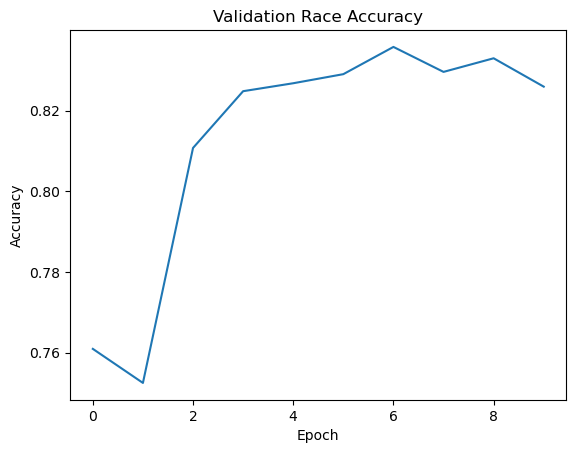

In [27]:
plt.figure()
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure()
plt.plot(history["val_age_mae"])
plt.title("Validation Age MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.show()

plt.figure()
plt.plot(history["val_gender_acc"])
plt.title("Validation Gender Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

plt.figure()
plt.plot(history["val_race_acc"])
plt.title("Validation Race Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

## Thresholding

Load trained 3 head model.

In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet_model = MultiTaskResNet(num_races=5).to(device)

checkpoint = torch.load("best_resnet_3head.pt", map_location=device)
resnet_model.load_state_dict(checkpoint["model_state_dict"])
# resnet_model.eval()

<All keys matched successfully>

Adjust the thresholds of the 3 head model.

In [30]:
def get_predictions_for_thresholding(model, loader, device):
    model.eval()
    results = []

    with torch.no_grad():
        for images, ages, genders, races, age_bins in loader:
            images = images.to(device)

            age_pred, gender_logit, race_logits = model(images)

            gender_prob = torch.sigmoid(gender_logit)
            gender_pred = (gender_prob >= 0.5).float()
            pred_race = torch.argmax(race_logits, dim=1)

            for i in range(len(images)):
                true_gender_num = int(genders[i].item())
                pred_gender_num = int(gender_pred[i].item())

                true_race_num = int(races[i].item())
                pred_race_num = int(pred_race[i].item())

                results.append({
                    "true_age": float(ages[i].item()),
                    "pred_age": float(age_pred[i].item()),
                    "age_error": float(age_pred[i].item() - ages[i].item()),
                    
                    "true_gender_num": true_gender_num,  # number
                    "pred_gender_num": pred_gender_num,
                    "true_gender": gender_map[true_gender_num],   # string
                    "pred_gender": gender_map[pred_gender_num],
                    "gender_prob": float(gender_prob[i].item()),
                    "gender_correct": int(pred_gender_num == true_gender_num),

                    "true_race_num": true_race_num,
                    "pred_race_num": pred_race_num,
                    "true_race": race_map[true_race_num],
                    "pred_race": race_map[pred_race_num],

                    "age_bin": str(age_bins[i])
                })

    return pd.DataFrame(results)

In [31]:
def choose_thresholds_by_predicted_race(val_results, min_count=20, max_dev=0.25):
    low = 0.5 - max_dev
    high = 0.5 + max_dev
    threshold_grid = np.linspace(low, high, 61)

    thresholds = {}

    for race_id in sorted(val_results["pred_race_num"].unique()):
        subset = val_results[val_results["pred_race_num"] == race_id].copy()

        if len(subset) < min_count:
            thresholds[race_id] = 0.5
            continue

        best_threshold = 0.5
        best_acc = -1.0

        for t in threshold_grid:
            preds = (subset["gender_prob"] >= t).astype(int)
            acc = (preds == subset["true_gender_num"]).mean()

            if acc > best_acc:
                best_acc = acc
                best_threshold = float(t)

        thresholds[race_id] = best_threshold

    return thresholds

In [32]:
def apply_race_specific_gender_thresholds(results_df, thresholds):
    out = results_df.copy()

    out["gender_threshold"] = out["pred_race_num"].map(thresholds).fillna(0.5)

    out["pred_gender_adjusted"] = (
        out["gender_prob"] >= out["gender_threshold"]
    ).astype(int)

    out["gender_correct_adjusted"] = (
        out["pred_gender_adjusted"] == out["true_gender_num"]
    ).astype(int)

    return out

In [33]:
val_results = get_predictions_for_thresholding(resnet_model, val_loader, device)
thresholds = choose_thresholds_by_predicted_race(val_results)

print("Thresholds:", thresholds)

test_results_default = get_predictions_for_thresholding(resnet_model, test_loader, device)
test_results_adjusted = apply_race_specific_gender_thresholds(
    test_results_default.copy(),
    thresholds
)

Thresholds: {0: 0.4916666666666667, 1: 0.3333333333333333, 2: 0.575, 3: 0.30833333333333335, 4: 0.5916666666666667}


Compare default and thresholded models.

In [41]:
age_order = ["0_5", "5_13", "13_20", "21_40", "41_60", "61_80", "80_plus"]
race_order = ["White", "Black", "Asian", "Indian", "Other"] 
gender_order = ["Male", "Female"]

def compute_heatmap_group_metrics(df, group_cols, gender_correct_col):
    grouped = df.groupby(group_cols)
    out = {}

    for name, sub in grouped:
        out[name] = {
            "gender_acc": sub[gender_correct_col].mean(),
            "age_mae": np.abs(sub["age_error"]).mean(),
            "count": len(sub)
        }

    return out

def to_matrix(metric_dict, row_name, col_name, value_key):
    rows = []

    for k, v in metric_dict.items():
        if not isinstance(k, tuple):
            k = (k,)
        rows.append((*k, v[value_key]))

    df = pd.DataFrame(rows, columns=[row_name, col_name, "value"])
    return df.pivot(index=row_name, columns=col_name, values="value")

def reorder_matrix(matrix, row_order=None, col_order=None):
    if row_order is not None:
        matrix = matrix.reindex(row_order)

    if col_order is not None:
        matrix = matrix.reindex(columns=col_order)

    return matrix

def plot_heatmap(matrix, title, cmap="Blues", fmt=".2f", vmin=None, vmax=None):
    plt.figure(figsize=(8, 6))

    if vmin is None:
        vmin = np.nanmin(matrix.values)
    if vmax is None:
        vmax = np.nanmax(matrix.values)

    im = plt.imshow(matrix, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)

    plt.title(title)
    plt.xticks(range(len(matrix.columns)), matrix.columns, rotation=45)
    plt.yticks(range(len(matrix.index)), matrix.index)

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            val = matrix.iloc[i, j]
            if not np.isnan(val):
                plt.text(
                    j, i,
                    format(val, fmt),
                    ha="center",
                    va="center",
                    color="black",
                    fontsize=9
                )

    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

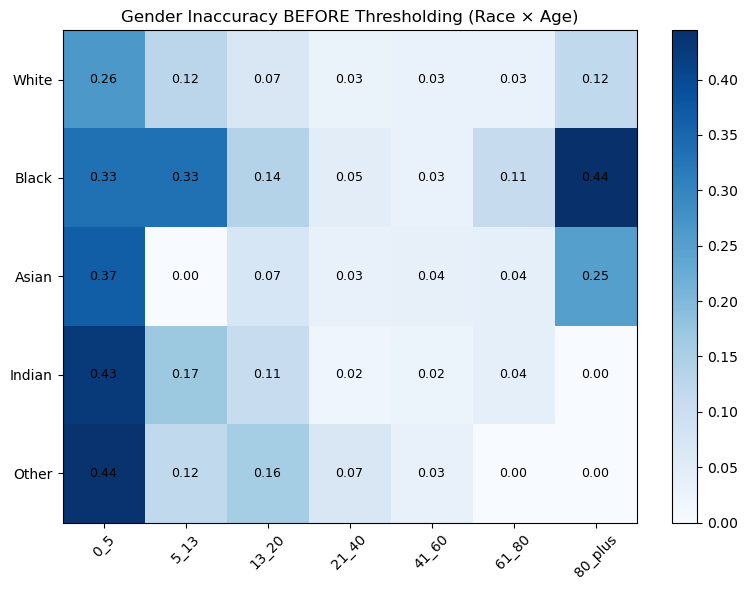

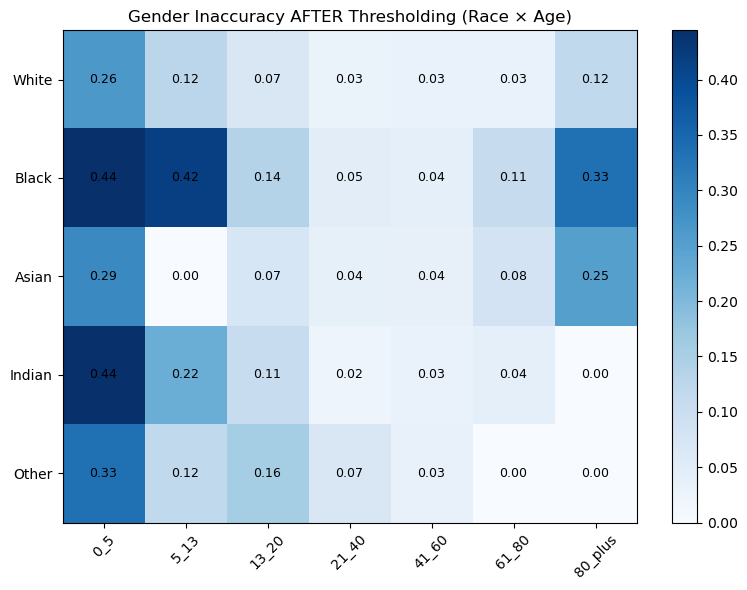

In [42]:
race_age_default = compute_heatmap_group_metrics(
    test_results_default,
    ["true_race", "age_bin"],
    gender_correct_col="gender_correct"
)

ra_acc_default = to_matrix(race_age_default, "race", "age_bin", "gender_acc")
ra_mae_default = to_matrix(race_age_default, "race", "age_bin", "age_mae")

ra_inacc_default = 1 - ra_acc_default

ra_acc_default = reorder_matrix(ra_acc_default, race_order, age_order)
ra_mae_default = reorder_matrix(ra_mae_default, race_order, age_order)
ra_inacc_default = reorder_matrix(ra_inacc_default, race_order, age_order)

# thresholded
race_age_adjusted = compute_heatmap_group_metrics(
    test_results_adjusted,
    ["true_race", "age_bin"],
    gender_correct_col="gender_correct_adjusted"
)

ra_acc_adjusted = to_matrix(race_age_adjusted, "race", "age_bin", "gender_acc")
ra_mae_adjusted = to_matrix(race_age_adjusted, "race", "age_bin", "age_mae")

ra_inacc_adjusted = 1 - ra_acc_adjusted

ra_acc_adjusted = reorder_matrix(ra_acc_adjusted, race_order, age_order)
ra_mae_adjusted = reorder_matrix(ra_mae_adjusted, race_order, age_order)
ra_inacc_adjusted = reorder_matrix(ra_inacc_adjusted, race_order, age_order)

#plot
vmin = min(ra_inacc_default.min().min(), ra_inacc_adjusted.min().min())
vmax = max(ra_inacc_default.max().max(), ra_inacc_adjusted.max().max())

plot_heatmap(
    ra_inacc_default,
    "Gender Inaccuracy BEFORE Thresholding (Race × Age)",
    cmap="Blues",
    vmin=vmin,
    vmax=vmax
)

plot_heatmap(
    ra_inacc_adjusted,
    "Gender Inaccuracy AFTER Thresholding (Race × Age)",
    cmap="Blues",
    vmin=vmin,
    vmax=vmax
)

Race x Gender

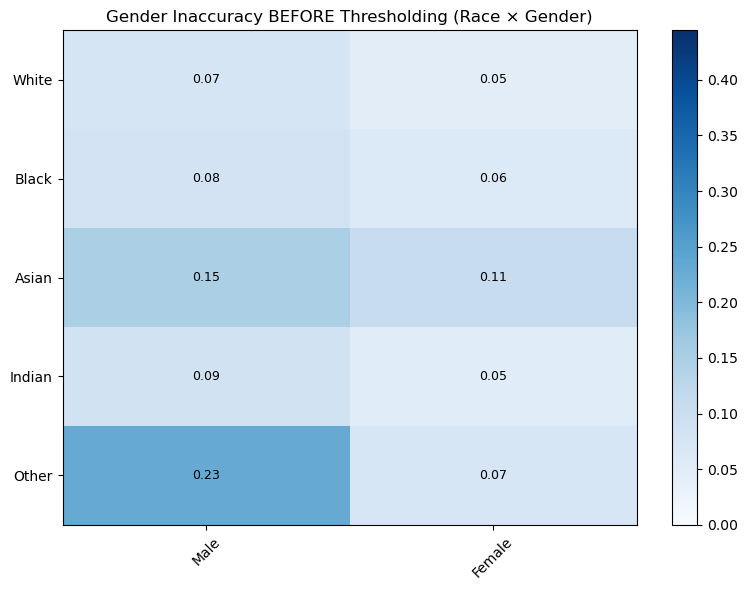

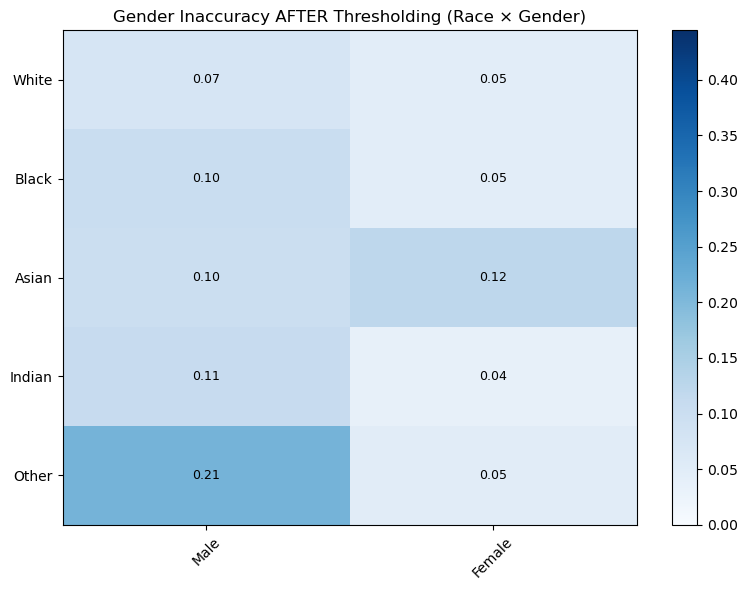

In [43]:
race_gender_default = compute_heatmap_group_metrics(
    test_results_default,
    ["true_race", "true_gender"],
    gender_correct_col="gender_correct"
)

rg_acc_default = to_matrix(race_gender_default, "race", "gender", "gender_acc")
rg_mae_default = to_matrix(race_gender_default, "race", "gender", "age_mae")
rg_inacc_default = 1 - rg_acc_default

rg_acc_default = reorder_matrix(rg_acc_default, race_order, gender_order)
rg_mae_default = reorder_matrix(rg_mae_default, race_order, gender_order)
rg_inacc_default = reorder_matrix(rg_inacc_default, race_order, gender_order)

#thresholded
race_gender_adjusted = compute_heatmap_group_metrics(
    test_results_adjusted,
    ["true_race", "true_gender"],
    gender_correct_col="gender_correct_adjusted"
)

rg_acc_adjusted = to_matrix(race_gender_adjusted, "race", "gender", "gender_acc")
rg_mae_adjusted = to_matrix(race_gender_adjusted, "race", "gender", "age_mae")
rg_inacc_adjusted = 1 - rg_acc_adjusted

rg_acc_adjusted = reorder_matrix(rg_acc_adjusted, race_order, gender_order)
rg_mae_adjusted = reorder_matrix(rg_mae_adjusted, race_order, gender_order)
rg_inacc_adjusted = reorder_matrix(rg_inacc_adjusted, race_order, gender_order)

#plot
vmin = min(rg_inacc_default.min().min(), ra_inacc_adjusted.min().min())
vmax = max(rg_inacc_default.max().max(), ra_inacc_adjusted.max().max())

plot_heatmap(
    rg_inacc_default,
    "Gender Inaccuracy BEFORE Thresholding (Race × Gender)",
    cmap="Blues",
    vmin=vmin,
    vmax=vmax
)

plot_heatmap(
    rg_inacc_adjusted,
    "Gender Inaccuracy AFTER Thresholding (Race × Gender)",
    cmap="Blues",
    vmin=vmin,
    vmax=vmax
)

# plot_heatmap(
#     rg_mae_default,
#     "Age MAE BEFORE Thresholding (Race × Gender)",
#     cmap="Reds"
# )

# plot_heatmap(
#     rg_mae_adjusted,
#     "Age MAE AFTER Thresholding (Race × Gender)",
#     cmap="Reds"
# )

Gender x Age

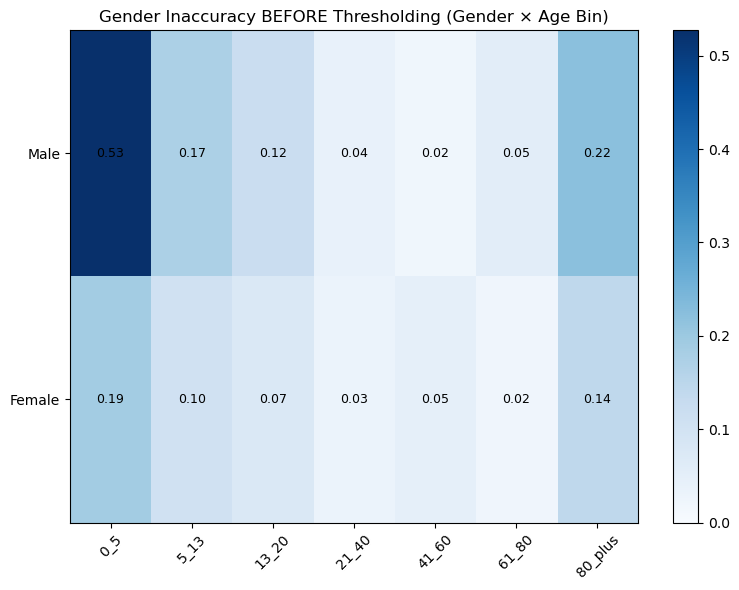

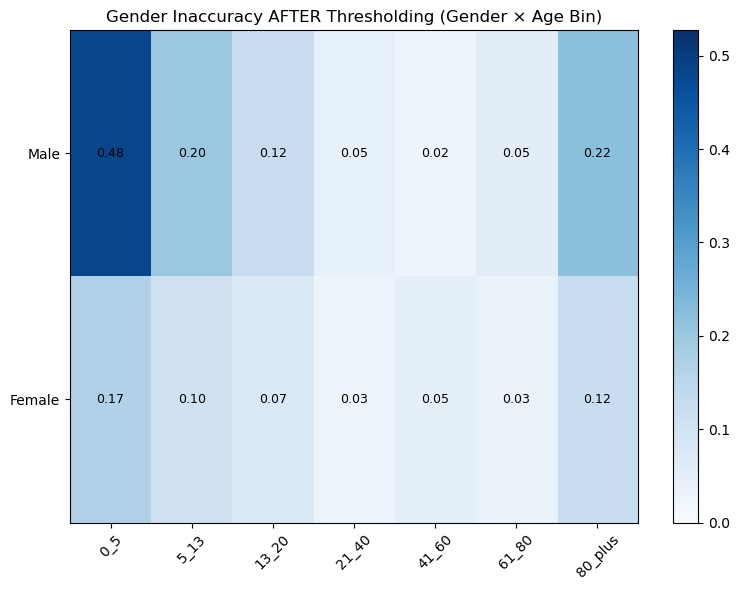

In [44]:
gender_age_default = compute_heatmap_group_metrics(
    test_results_default,
    ["true_gender", "age_bin"],
    gender_correct_col="gender_correct"
)

ga_acc_default = to_matrix(gender_age_default, "gender", "age_bin", "gender_acc")
ga_mae_default = to_matrix(gender_age_default, "gender", "age_bin", "age_mae")
ga_inacc_default = 1 - ga_acc_default

ga_acc_default = reorder_matrix(ga_acc_default, gender_order, age_order)
ga_mae_default = reorder_matrix(ga_mae_default, gender_order, age_order)
ga_inacc_default = reorder_matrix(ga_inacc_default, gender_order, age_order)

# thresholded
gender_age_adjusted = compute_heatmap_group_metrics(
    test_results_adjusted,
    ["true_gender", "age_bin"],
    gender_correct_col="gender_correct_adjusted"
)

ga_acc_adjusted = to_matrix(gender_age_adjusted, "gender", "age_bin", "gender_acc")
ga_mae_adjusted = to_matrix(gender_age_adjusted, "gender", "age_bin", "age_mae")
ga_inacc_adjusted = 1 - ga_acc_adjusted

ga_acc_adjusted = reorder_matrix(ga_acc_adjusted, gender_order, age_order)
ga_mae_adjusted = reorder_matrix(ga_mae_adjusted, gender_order, age_order)
ga_inacc_adjusted = reorder_matrix(ga_inacc_adjusted, gender_order, age_order)

# plot
vmin = min(ga_inacc_default.min().min(), ra_inacc_adjusted.min().min())
vmax = max(ga_inacc_default.max().max(), ra_inacc_adjusted.max().max())

plot_heatmap(
    ga_inacc_default,
    "Gender Inaccuracy BEFORE Thresholding (Gender × Age Bin)",
    cmap="Blues",
    vmin=vmin,
    vmax=vmax
)

plot_heatmap(
    ga_inacc_adjusted,
    "Gender Inaccuracy AFTER Thresholding (Gender × Age Bin)",
    cmap="Blues",
    vmin=vmin,
    vmax=vmax
)

# plot_heatmap(
#     ga_mae_default,
#     "Age MAE BEFORE Thresholding (Gender × Age Bin)",
#     cmap="Reds"
# )

# plot_heatmap(
#     ga_mae_adjusted,
#     "Age MAE AFTER Thresholding (Gender × Age Bin)",
#     cmap="Reds"
# )

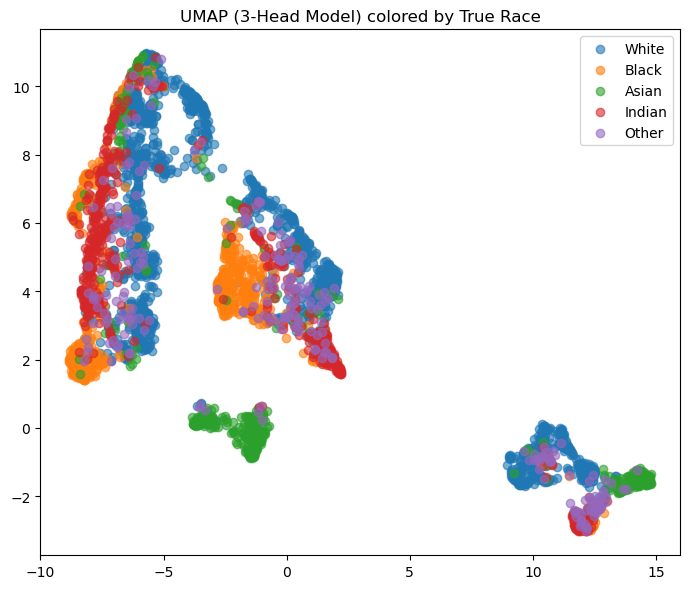

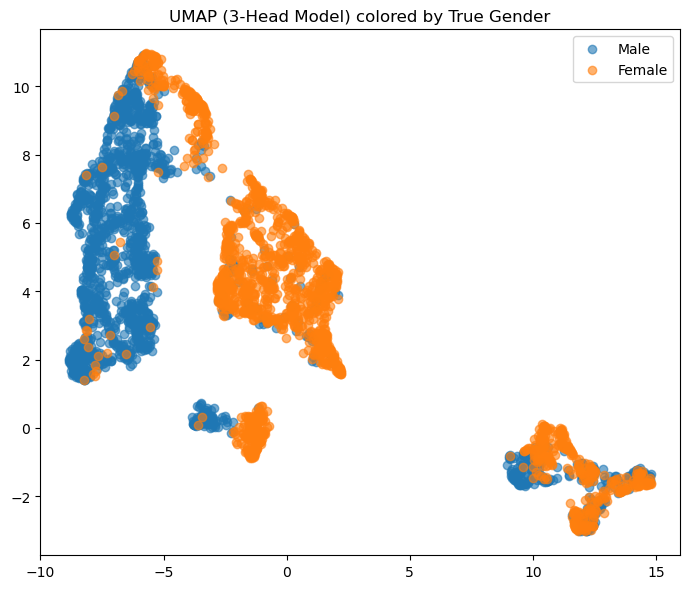

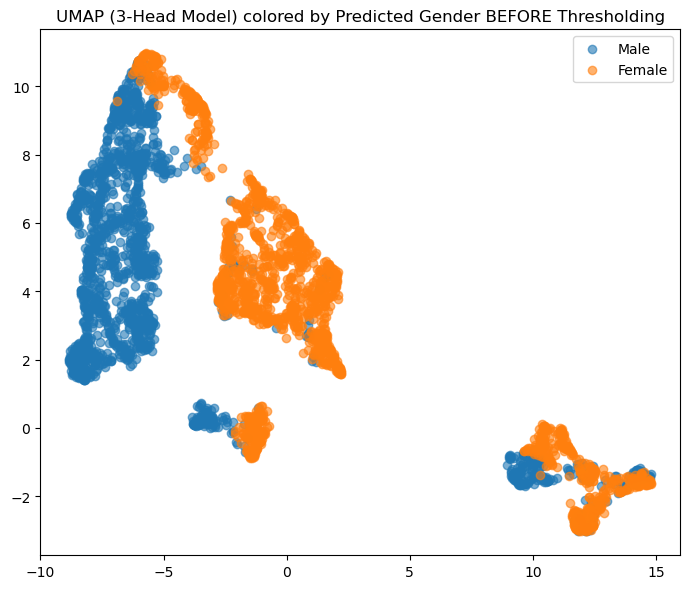

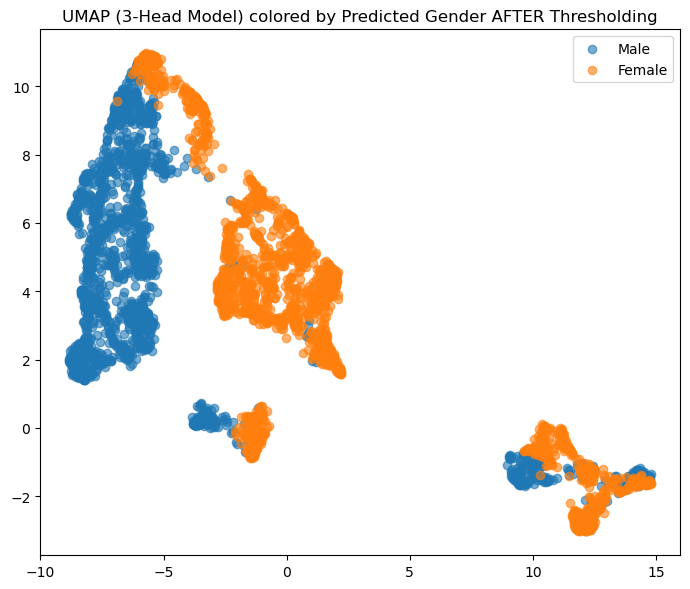

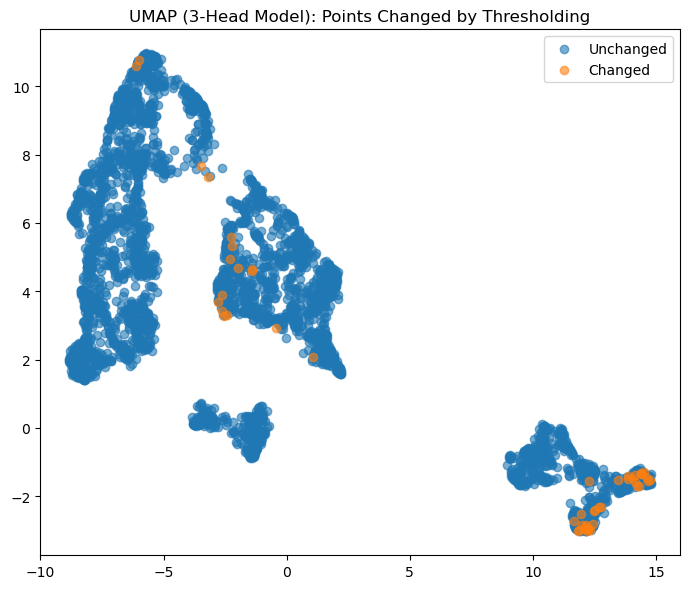

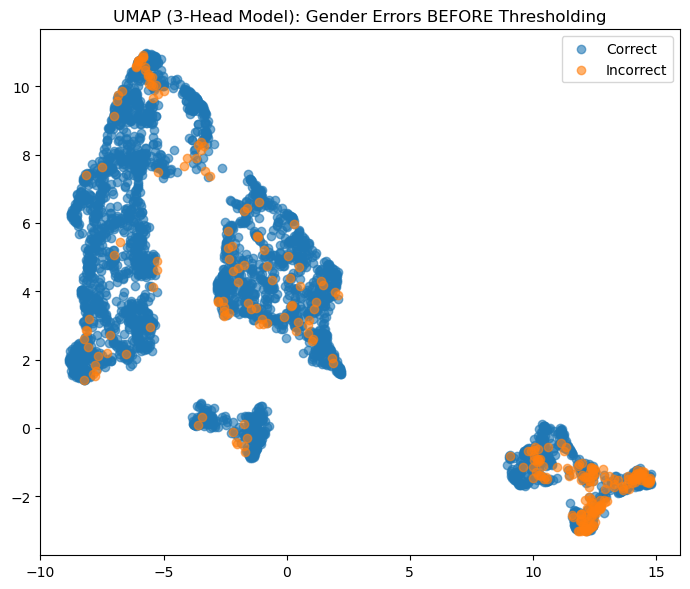

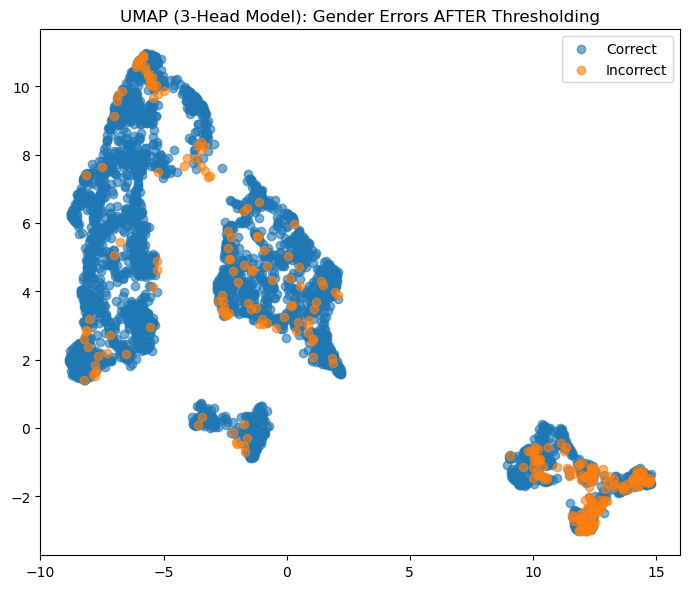

In [52]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import umap

# =========================================================
# 1. EXTRACT EMBEDDINGS + PREDICTIONS FROM 3-HEAD MODEL
# =========================================================

def collect_embeddings_and_predictions(model, loader, device):
    model.eval()

    all_embeddings = []
    results = []

    with torch.no_grad():
        for images, ages, genders, races, age_bins in loader:
            images = images.to(device)

            features = model.backbone(images)

            age_pred = model.age_head(features).squeeze(1)
            gender_logit = model.gender_head(features).squeeze(1)
            race_logits = model.race_head(features)

            gender_prob = torch.sigmoid(gender_logit)
            pred_gender_default = (gender_prob >= 0.5).int()
            pred_race = torch.argmax(race_logits, dim=1)

            all_embeddings.append(features.cpu())

            for i in range(len(images)):
                results.append({
                    "true_age": float(ages[i].item()),
                    "pred_age": float(age_pred[i].item()),
                    "age_error": float(age_pred[i].item() - ages[i].item()),

                    "true_gender_num": int(genders[i].item()),
                    "pred_gender_num": int(pred_gender_default[i].item()),
                    "gender_prob": float(gender_prob[i].item()),

                    "true_race_num": int(races[i].item()),
                    "pred_race_num": int(pred_race[i].item()),

                    "true_race": race_map[int(races[i].item())],
                    "pred_race": race_map[int(pred_race[i].item())],
                    "true_gender": gender_map[int(genders[i].item())],

                    "age_bin": str(age_bins[i])
                })

    emb = torch.cat(all_embeddings, dim=0).numpy()
    df_preds = pd.DataFrame(results)

    return emb, df_preds

    emb = torch.cat(all_embeddings, dim=0).numpy()
    df_preds = pd.DataFrame(results)

    return emb, df_preds


# =========================================================
# 2. APPLY THRESHOLDS TO GET ADJUSTED GENDER PREDICTIONS
# =========================================================

def apply_race_specific_gender_thresholds(results_df, thresholds):
    out = results_df.copy()

    out["gender_threshold"] = out["pred_race_num"].map(thresholds).fillna(0.5)
    out["pred_gender_adjusted"] = (
        out["gender_prob"] >= out["gender_threshold"]
    ).astype(int)

    out["gender_correct_default"] = (
        out["pred_gender_num"] == out["true_gender_num"]
    ).astype(int)

    out["gender_correct_adjusted"] = (
        out["pred_gender_adjusted"] == out["true_gender_num"]
    ).astype(int)

    return out


# =========================================================
# 3. SIMPLE UMAP PLOTTING HELPER
# =========================================================

def plot_umap(X_umap, labels, label_map=None, title=""):
    plt.figure(figsize=(7, 6))

    labels = np.array(labels)
    unique_labels = np.unique(labels)

    for lab in unique_labels:
        mask = labels == lab
        name = label_map[lab] if label_map is not None and lab in label_map else str(lab)

        plt.scatter(
            X_umap[mask, 0],
            X_umap[mask, 1],
            label=name,
            alpha=0.6
        )

    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================================================
# 4. COLLECT TEST EMBEDDINGS + DEFAULT PREDICTIONS
# =========================================================

embeddings_3head, umap_results = collect_embeddings_and_predictions(
    resnet_model,
    test_loader,
    device
)

# apply thresholding
umap_results = apply_race_specific_gender_thresholds(umap_results, thresholds)


# =========================================================
# 5. RECALCULATE UMAP IN THIS NOTEBOOK
# =========================================================

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

X_umap_3head = reducer.fit_transform(embeddings_3head)


# =========================================================
# 6. PLOT TRUE LABELS / DEFAULT / THRESHOLDED / CHANGES
# =========================================================

# true race
plot_umap(
    X_umap_3head,
    umap_results["true_race_num"].values,
    race_map,
    "UMAP (3-Head Model) colored by True Race"
)

# true gender
plot_umap(
    X_umap_3head,
    umap_results["true_gender_num"].values,
    gender_map,
    "UMAP (3-Head Model) colored by True Gender"
)

# default gender prediction
plot_umap(
    X_umap_3head,
    umap_results["pred_gender_num"].values,
    gender_map,
    "UMAP (3-Head Model) colored by Predicted Gender BEFORE Thresholding"
)

# thresholded gender prediction
plot_umap(
    X_umap_3head,
    umap_results["pred_gender_adjusted"].values,
    gender_map,
    "UMAP (3-Head Model) colored by Predicted Gender AFTER Thresholding"
)

# changed vs unchanged
changed = (
    umap_results["pred_gender_num"].values !=
    umap_results["pred_gender_adjusted"].values
).astype(int)

change_map = {0: "Unchanged", 1: "Changed"}

plot_umap(
    X_umap_3head,
    changed,
    change_map,
    "UMAP (3-Head Model): Points Changed by Thresholding"
)

# default errors
default_errors = (
    umap_results["pred_gender_num"].values !=
    umap_results["true_gender_num"].values
).astype(int)

error_map = {0: "Correct", 1: "Incorrect"}

plot_umap(
    X_umap_3head,
    default_errors,
    error_map,
    "UMAP (3-Head Model): Gender Errors BEFORE Thresholding"
)

# adjusted errors
adjusted_errors = (
    umap_results["pred_gender_adjusted"].values !=
    umap_results["true_gender_num"].values
).astype(int)

plot_umap(
    X_umap_3head,
    adjusted_errors,
    error_map,
    "UMAP (3-Head Model): Gender Errors AFTER Thresholding"
)

In [53]:
print((pred_default != pred_adjusted).sum())

50


In [54]:
print(test_results_adjusted["gender_correct_adjusted"].mean() -
      test_results_default["gender_correct"].mean())

0.0016872890888638414
